In [1]:
from typing import Any, Callable

import numpy as np
from langchain_core.tools import tool
import io
import base64
from PIL import Image

# ---------------------------------------------------------------------------
# Camera initialisation
# Lazy singleton — camera is opened once on first call to get_observation,
# not at import time, so the agent can still be imported without hardware.
# ---------------------------------------------------------------------------

_camera = None          # lerobot Camera instance
_camera_error: str = "" # set if init failed, surfaced in capability result


def _init_camera() -> None:
    """Open the camera once and cache it.  Tries RealSense first if configured."""
    global _camera, _camera_error

    if _camera is not None:
        return  # already open

    use_realsense = True

    if use_realsense:
        _init_realsense()
    else:
        _init_opencv()


def _init_realsense() -> None:
    """Attempt to open an Intel RealSense camera."""
    global _camera, _camera_error
    try:
        from lerobot.cameras.realsense.camera_realsense import RealSenseCamera
        from lerobot.cameras.realsense.configuration_realsense import RealSenseCameraConfig

        serial = ""  # leave blank to use first found
        config = RealSenseCameraConfig(
            serial_number_or_name=serial if serial else _find_first_realsense_serial(),
            fps=15,
            width=640,
            height=480,
        )
        cam = RealSenseCamera(config)
        cam.connect(warmup=True)
        _camera = cam
        print("RealSense camera opened.")
    except Exception as exc:
        _camera_error = f"RealSense init failed: {exc}"
        print(_camera_error)
        print("Falling back to OpenCV camera.")
        _init_opencv()


def _find_first_realsense_serial() -> str:
    """Return the serial number of the first attached RealSense device."""
    from lerobot.cameras.realsense.camera_realsense import RealSenseCamera
    cameras = RealSenseCamera.find_cameras()
    if not cameras:
        raise RuntimeError("No RealSense cameras found.")
    return str(cameras[0]["id"])


def _init_opencv() -> None:
    """Open an OpenCV camera at the configured index."""
    global _camera, _camera_error
    try:
        from lerobot.cameras.opencv.camera_opencv import OpenCVCamera
        from lerobot.cameras.opencv.configuration_opencv import OpenCVCameraConfig

        index = int("4")
        config = OpenCVCameraConfig(
            index_or_path=index,
            fps=30,
            width=640,
            height=480,
        )
        cam = OpenCVCamera(config)
        cam.connect(warmup=True)
        _camera = cam
        print(f"OpenCV camera opened at index {index}.")
    except Exception as exc:
        _camera_error = f"OpenCV camera init failed: {exc}"
        print(_camera_error)


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _frame_to_base64(frame_rgb):
    from PIL import Image as PILImage   # local import avoids any global shadowing
    import io, base64

    img = PILImage.fromarray(frame_rgb)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


def _run_detection(frame_rgb: np.ndarray, target_object: str) -> list[dict[str, Any]]:
    """
    Object detection placeholder.

    Replace the body of this function with your YOLO World inference when ready.
    The expected return format is:
        [{"label": str, "id": str, "x": float, "y": float, "z": float,
          "confidence": float, "bbox_px": [x1, y1, x2, y2]}, ...]

    For now we return plausible-looking stub detections so the agent can
    exercise its reasoning loop end-to-end.
    """
    # --- STUB ---
    # When you have the model:
    #   from inference import get_model
    #   model = get_model("yolo-world-l", api_key=os.getenv("ROBOFLOW_API_KEY"))
    #   results = model.infer(frame_rgb, text=target_object, confidence=0.3)[0]
    #   return [ ... parse results.predictions ... ]
    h, w = frame_rgb.shape[:2]
    stub_objects = [
        {"label": target_object, "id": f"{target_object}_0",
         "x": 0.12, "y": -0.05, "z": 0.30, "confidence": 0.93,
         "bbox_px": [w//4, h//4, w//2, h//2]},
        {"label": target_object, "id": f"{target_object}_1",
         "x": 0.22, "y":  0.03, "z": 0.29, "confidence": 0.88,
         "bbox_px": [w//2, h//3, 3*w//4, 2*h//3]},
    ]
    return stub_objects

In [2]:
# ---------------------------------------------------------------------------
# Capability implementations
# ---------------------------------------------------------------------------

def _get_observation(target_object: str = "screw", **kwargs: Any) -> dict[str, Any]:
    """
    Capture a real camera frame, run detection (stubbed), and return results.

    The returned dict includes:
      frame_b64   — base64-encoded PNG of the captured frame (rendered by the UI)
      detected    — list of detected objects with 3-D positions
      camera_info — which camera backend was used
    """
    # Ensure camera is open
    _init_camera()

    frame_b64: str = ""
    camera_info: str = ""
    detected: list[dict[str, Any]] = []
    error: str = ""

    if _camera is None:
        # Camera could not be opened — return the error so the agent knows
        error = _camera_error or "Camera not available."
        return {
            "capability": "get_observation",
            "target": target_object,
            "detected": [],
            "count": 0,
            "frame_b64": "",
            "camera_info": "none",
            "error": error,
            "note": "Camera unavailable. Check USB connection or set USE_REALSENSE=true.",
        }

    try:
        frame_rgb = _camera.read()          # (H, W, 3) uint8 RGB
        frame_b64 = _frame_to_base64(frame_rgb)
        camera_info = type(_camera).__name__

        # Run detection (stub until YOLO is wired in)
        detected = _run_detection(frame_rgb, target_object)

    except Exception as exc:
        error = f"Frame capture failed: {exc}"
        print(error)

    return {
        "capability": "get_observation",
        "target": target_object,
        "detected": detected,
        "count": len(detected),
        "frame_b64": frame_b64,   # base64 PNG — rendered by ui.py
        "camera_info": camera_info,
        "error": error,
        "note": (
            "Detection results are STUB placeholders. "
            "Wire _run_detection() to YOLO World when model is ready."
        ),
    }

RealSense camera opened.
Captured via: RealSenseCamera


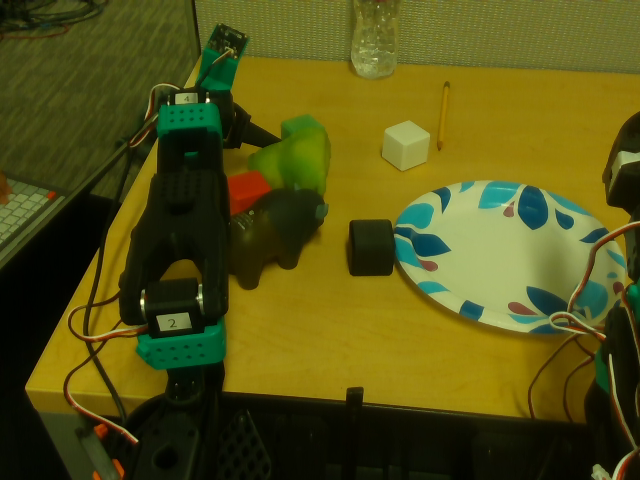

In [3]:
from IPython.display import display, Image
from base64 import b64decode

# 1. Get the observation
obs = _get_observation(target_object="screw")

# 2. Extract and decode the base64 string
if obs["frame_b64"]:
    image_data = b64decode(obs["frame_b64"])
    
    # 3. Display it
    print(f"Captured via: {obs['camera_info']}")
    display(Image(data=image_data))
else:
    print(f"Error: {obs['error']}")